# Denetimli Öğrenme — Lojistik Regresyon ile Sınıflandırma

## Lojistik Regresyon Nedir?

Önceki bölümde lineer regresyonu öğrendiniz ve gelecekteki değerleri tahmin etmek için nasıl kullanabileceğinizi gördünüz. Bu bölümde, başka bir üst denetimli makine öğrenmesi algoritması olan logistik regresyonu öğreneceksiniz. Lineer regresyonun aksine, logistik regresyon bir dizi girdi verildiğinde bir sayısal değişkenin değerini tahmin etmeye çalışmaz. Bunun yerine, logistik regresyonun çıktısı, belirli bir sınıfa ait bir giriş noktasının olasılığıdır. Logistik regresyonun çıktısı her zaman [0,1] aralığında olur.

Logistik regresyonun kullanımını anlamak için Şekil 7.1'de gösterilen örneği düşünün. Seçmen geliri ve oy tercihleri hakkında bilgi içeren bir veri setiniz olduğunu varsayalım. Bu veri seti için, düşük gelirli seçmenlerin genellikle aday B'ye, yüksek gelirli seçmenlerin ise aday A'ya oy verme eğiliminde olduğunu görebilirsiniz.

Bu veri setiyle, gelecekteki seçmenlerin gelir seviyelerine göre hangi adaya oy vereceklerini tahmin etmeye çok ilgilisiniz. İlk bakışta, şimdi öğrendiğiniz şeyi bu soruna uygulama eğiliminde olabilirsiniz; yani, lineer regresyon kullanma. Şekil 7.2, bu soruna lineer regresyon uygulandığında nasıl göründüğünü göstermektedir.

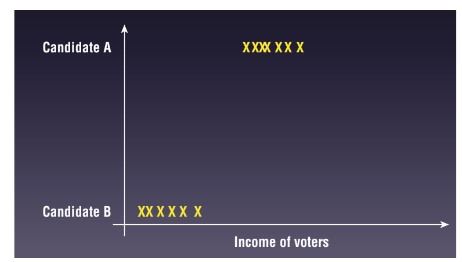

In [1]:
from IPython.display import Image
Image('Şekil 7.1.jpg')

**Şekil 7.1:** Bazı problemlerin ikili çıktıları vardır

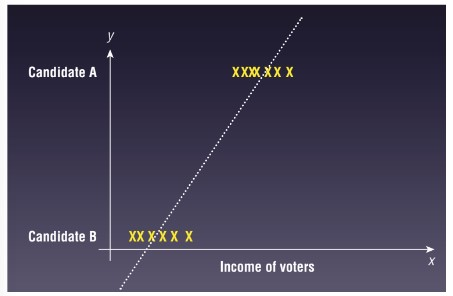

In [4]:
Image('Şekil 7.2.jpg')

**Şekil 7.2:** Oy tercihleri problemi için lineer regresyon kullanmak tuhaf değerlere yol açar

Lineer regresyonun ana problemi, tahmin edilen değerin her zaman beklenen aralıkta olmamasıdır. Çok düşük gelirli bir seçmenin durumunu (0'a yakın) düşünün ve grafikten tahmin edilen sonucun negatif bir değer olduğunu görebilirsiniz. Gerçekten istediğiniz, bir olayın gerçekleşme olasılığını temsil eden bir değer olarak tahmini 0 ile 1 arasında döndüren bir yol olmasıdır. Şekil 7.3, logistik regresyonun bu problemi nasıl çözdüğünü göstermektedir. Noktaların arasından geçen düz bir çizgi çizmek yerine, tüm noktaları grafikte sığdırmaya çalışmak için eğri bir çizgi kullanırsınız.

Logistik regresyon kullanılarak, çıktı 0 ile 1 arasında bir değer olacaktır. Bu değer, 0.5'e eşit veya ondan küçük olan her şey (eşik olarak bilinir) aday B'ye oy olarak kabul edilirken, 0.5'ten büyük her şey aday A'ya oy olarak kabul edilir.

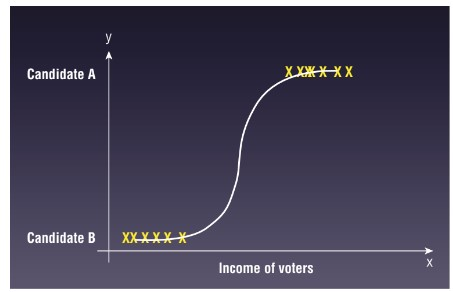

In [9]:
Image('Şekil 7.3.jpg')

**Şekil 7.3:** Logistik regresyon, belirli bir değil, bir sonucun olasılığını tahmin eder

## Olasılıkları Anlamak

Logistik regresyon algoritmasının detaylarını tartışmadan önce, ilk olarak önemli bir terim olan "olasılık" hakkında konuşmamız gerekiyor. Olasılıklar, başarı olasılığının başarısızlık olasılığına oranı olarak tanımlanır (Şekil 7.4'e bakınız).

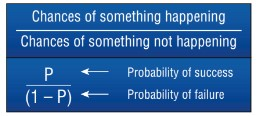

In [10]:
Image('Şekil 7.4.jpg')

**Şekil 7.4:** Bir olayın olma olasılığını hesaplama yöntemi

Örneğin, bir madeni para attığınızda tura gelme olasılığı 1'dir. Bu, tura gelme olasılığınızın 0.5 ve yazı gelme olasılığınızın da 0.5 olduğu anlamına gelir. Tura gelme olasılığının 1 olduğunu söylediğinizde, tura gelme şansınızın %50 olduğu anlamına gelir.

Ancak madeni para öyle bir şekilde düzenlenmişse ki tura gelme olasılığınız 0.8 ve yazı gelme olasılığınız 0.2 ise, tura gelme olasılığı 0.8/0.2 = 4'tür. Yani, yazıya göre tura gelme olasılığınız 4 kat daha fazladır. Benzer şekilde, yazı gelme olasılığı 0.2/0.8 = 0.25'tir.

## Logit Fonksiyonu

Olasılıklara doğal logaritma fonksiyonunu uyguladığınızda, logit fonksiyonunu elde edersiniz. Logit fonksiyonu, olasılıkların logaritmasıdır (Şekil 7.5'e bakınız).

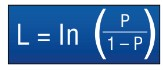

In [12]:
Image('Şekil 7.5.jpg')

Logit fonksiyonu, (0, 1) aralığındaki bir değişkeni (–∞, ∞) aralığındaki yeni bir değişkene dönüştürür. Bu ilişkiyi görmek için aşağıdaki kod parçasını kullanabilirsiniz:

Text(0, 0.5, 'Logit - L')

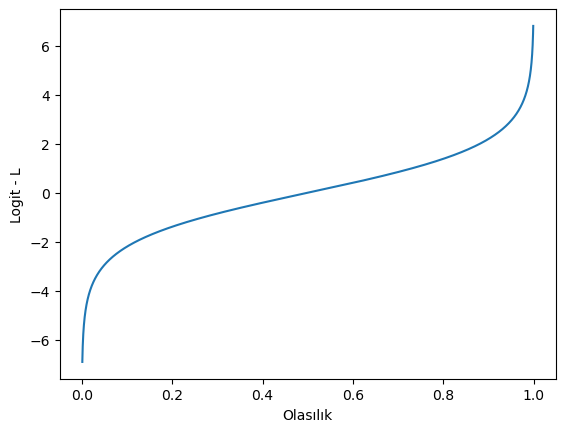

In [13]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def logit(x):
    return np.log( x / (1 - x) )

x = np.arange(0.001, 0.999, 0.0001)
y = [logit(n) for n in x]

plt.plot(x, y)
plt.xlabel("Olasılık")
plt.ylabel("Logit - L")

Şekil 7.6, yukarıdaki kod parçasını kullanarak çizdirilen logit eğrisini göstermektedir.

Text(0, 0.5, 'Logit - L')

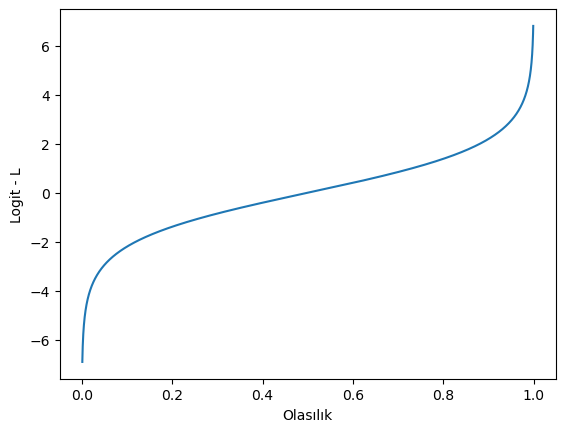

In [15]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def logit(x):
    return np.log( x / (1 - x) )

x = np.arange(0.001, 0.999, 0.0001)
y = [logit(n) for n in x]

plt.plot(x, y)
plt.xlabel("Olasılık")
plt.ylabel("Logit - L")

**Şekil 7.6:** Logit eğrisi

## Sigmoid Eğrisi

Logit eğrisi için x-ekseninin olasılık ve y-ekseninin gerçek sayı aralığı olduğunu gözlemleyin. Lojistik regresyon için gerçekte istediğiniz, gerçek sayı sistemindeki sayıları olasılıklara eşlemek olan bir fonksiyondur. Bu, logit eğrisinin eksenlerini çevirdiğinizde elde ettiğiniz şeydir (Şekil 7.7'ye bakınız).

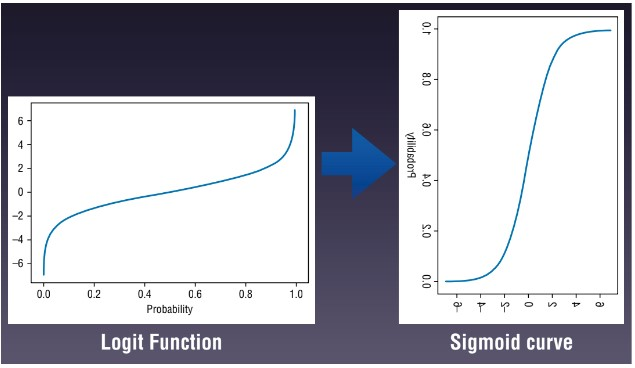

In [18]:
Image('Şekil 7.7.jpg')

**Şekil 7.7:** Logit eğrisini Sigmoid eğrisine döndürme

Eksenleri çevirdiğinizde elde ettiğiniz eğriye Sigmoid eğrisi denir. Sigmoid eğrisi, logit fonksiyonunun tersi olan Sigmoid fonksiyonu kullanılarak elde edilir. Sigmoid fonksiyonu, (–∞, ∞) aralığındaki değerleri (0, 1) aralığındaki sayılara dönüştürmek için kullanılır. Sigmoid fonksiyonu Şekil 7.8'de gösterilmektedir.

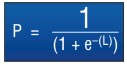

In [21]:
Image('Şekil 7.8.jpg')

**Şekil 7.8:** Sigmoid fonksiyonu için formül

Aşağıdaki kod parçası, sigmoid eğrisinin nasıl elde edildiğini göstermektedir:

Text(0, 0.5, 'Olasılık')

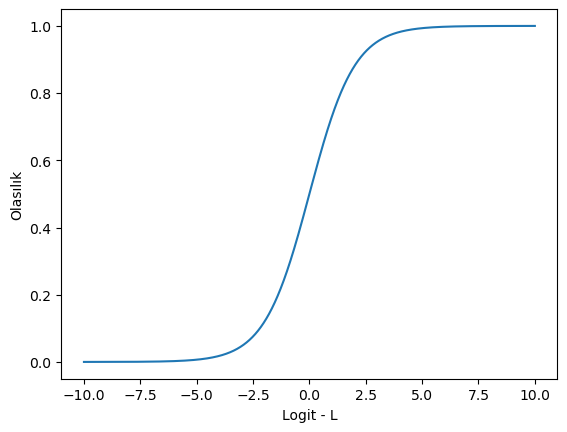

In [22]:
def sigmoid(x):
    return (1 / (1 + np.exp(-x)))

x = np.arange(-10, 10, 0.0001)
y = [sigmoid(n) for n in x]

plt.plot(x, y)
plt.xlabel("Logit - L")
plt.ylabel("Olasılık")

**Şekil 7.9:** sigmoid eğrisini göstermektedir.

Lineer regresyonda (Bölüm 5'te açıklandığı gibi) tüm noktalardan geçen düz bir çizgi çizmeye çalıştığınız gibi, lojistik regresyonda da tüm noktalardan geçen bir sigmoid eğrisi çizmek isteriz. Matematiksel olarak, bu Şekil 7.10'da gösterilen formülle ifade edilebilir.

Text(0, 0.5, 'Olasılık')

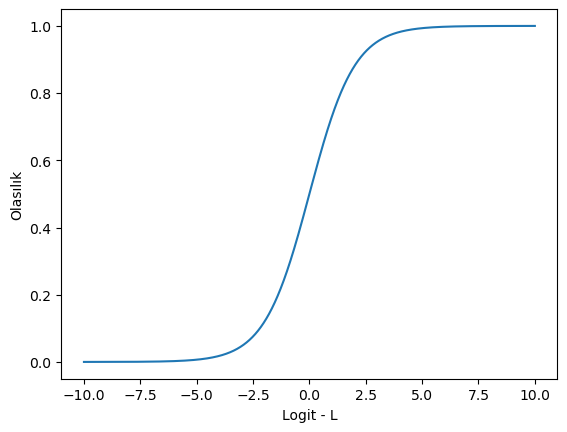

In [25]:
def sigmoid(x):
    return (1 / (1 + np.exp(-x)))

x = np.arange(-10, 10, 0.0001)
y = [sigmoid(n) for n in x]

plt.plot(x, y)
plt.xlabel("Logit - L")
plt.ylabel("Olasılık")

**Şekil 7.9:** Matplotlib kullanılarak çizdirilen sigmoid eğrisi

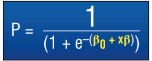

In [26]:
Image('Şekil 7.10.jpg')

**Şekil 7.10:** Sigmoid fonksiyonunu intercept ve katsayı kullanarak ifade etme

Şekil 7.8 ve 7.10'da gösterilen formül arasındaki ana farkın, artık L'nin β0 ve xβ ile değiştirilmiş olmasıdır. Katsayılar β0 ve β bilinmemektedir ve bunlar, Maksimum Olabilirlik Tahmini (MLE) olarak bilinen bir teknik kullanılarak mevcut eğitim verilerine dayanarak tahmin edilmelidir. Lojistik regresyonda, β0 intercept olarak bilinir ve xβ katsayı olarak bilinir.

## Meme Kanseri Wisconsin (Tanısal) Veri Seti Kullanımı 

Scikit-learn, Meme Kanseri Wisconsin (Tanısal) Veri Seti ile birlikte gelir. Bu, sıklıkla ikili sınıflandırmaları göstermek için kullanılan klasik bir veri setidir. Bu veri seti 30 özellik içerir ve bunlar bir meme kitlesi için dijitalleştirilmiş bir ince iğne aspiratının (FNA) görüntüsünden hesaplanmıştır. Veri setinin etiketi ikili bir sınıflandırmadır—M kötü huylu veya B iyi huylu. Daha fazla bilgi için ilgilenen okuyucular, https://archive.ics.uci.edu/ml/datasets/Breast+Cancer+Wisconsin+(Diagnostic) adresine başvurabilirler.

### Özellikler Arasındaki İlişkiyi İnceleme

Sklearn'den datasets modülünü içe aktararak Meme Kanseri veri setini yükleyebilirsiniz. Ardından load_breast_cancer() fonksiyonunu kullanın:

In [27]:
from sklearn.datasets import load_breast_cancer
cancer = load_breast_cancer()

Meme Kanseri veri seti yüklendikten sonra, bazı özellikler arasındaki ilişkileri incelemek yararlıdır.

### 2D'de Özellikleri Çizme

Başlangıç olarak, veri setinin ilk iki özelliğini 2D'de çizelim ve ilişkilerini inceleyelim. Aşağıdaki kod parçası:
- Meme Kanseri veri setini yükler
- Veri setinin ilk iki özelliğini iki boyutlu bir listeye kopyalar
- İki özellik için noktaların dağılımını gösteren bir saçılma grafiği çizer
- Kötü huylu büyümeleri kırmızı, iyi huylu büyümeleri mavi olarak gösterir

Şekil 7.11, noktalar arasındaki ilişkiyi gösteren saçılma grafiğini göstermektedir.

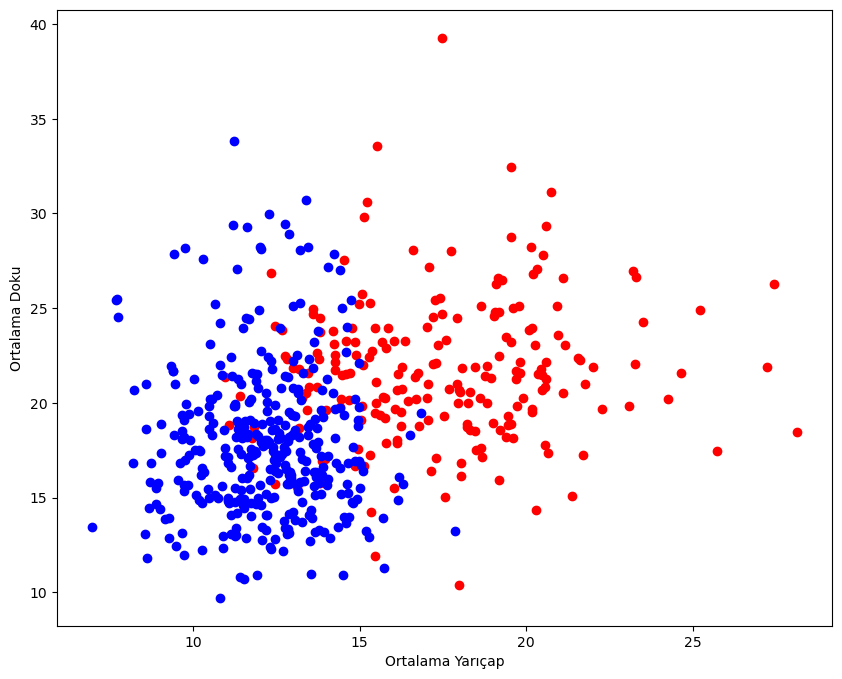

In [28]:
%matplotlib inline
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer()

# --- Veri setinden 2 boyutlu bir liste oluşturma ---
X = []
for target in range(2):
    X.append([[], []])

for i in range(len(cancer.data)):
    if cancer.target[i] == 0:
        X[0][0].append(cancer.data[i][0])  # ilk özellik - ortalama yarıçap
        X[0][1].append(cancer.data[i][1])  # ikinci özellik - ortalama doku
    else:
        X[1][0].append(cancer.data[i][0])
        X[1][1].append(cancer.data[i][1])

colors = ("r", "b")  # r: kötü huylu, b: iyi huylu

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111)

for target, color in zip(range(2), colors):
    ax.scatter(X[target][0], X[target][1], c=color)

ax.set_xlabel("Ortalama Yarıçap")
ax.set_ylabel("Ortalama Doku")
plt.show()

**Şekil 7.11:** Tümörün ortalama yarıçapı ve ortalama dokusu arasındaki ilişkileri gösteren dağılım grafiği

Bu saçılma grafiğinden, tümörün yarıçapının büyüdükçe ve dokusunun arttıkça, kötü huylu olarak teşhis edilme olasılığının arttığını görebilirsiniz.

### 3D'de Çizme

Önceki bölümde, iki özellik kullanarak noktaları bir saçılma grafiği ile çizdiniz. İki özellikten daha fazlasını görselleştirebilmek ilginç olacaktır. Bu durumda, üç özellik arasındaki ilişkileri görselleştirmeyi deneyelim.

Matplotlib'i kullanarak 3D grafik çizebilirsiniz. Aşağıdaki kod parçası, bu işlemin nasıl yapıldığını göstermektedir:

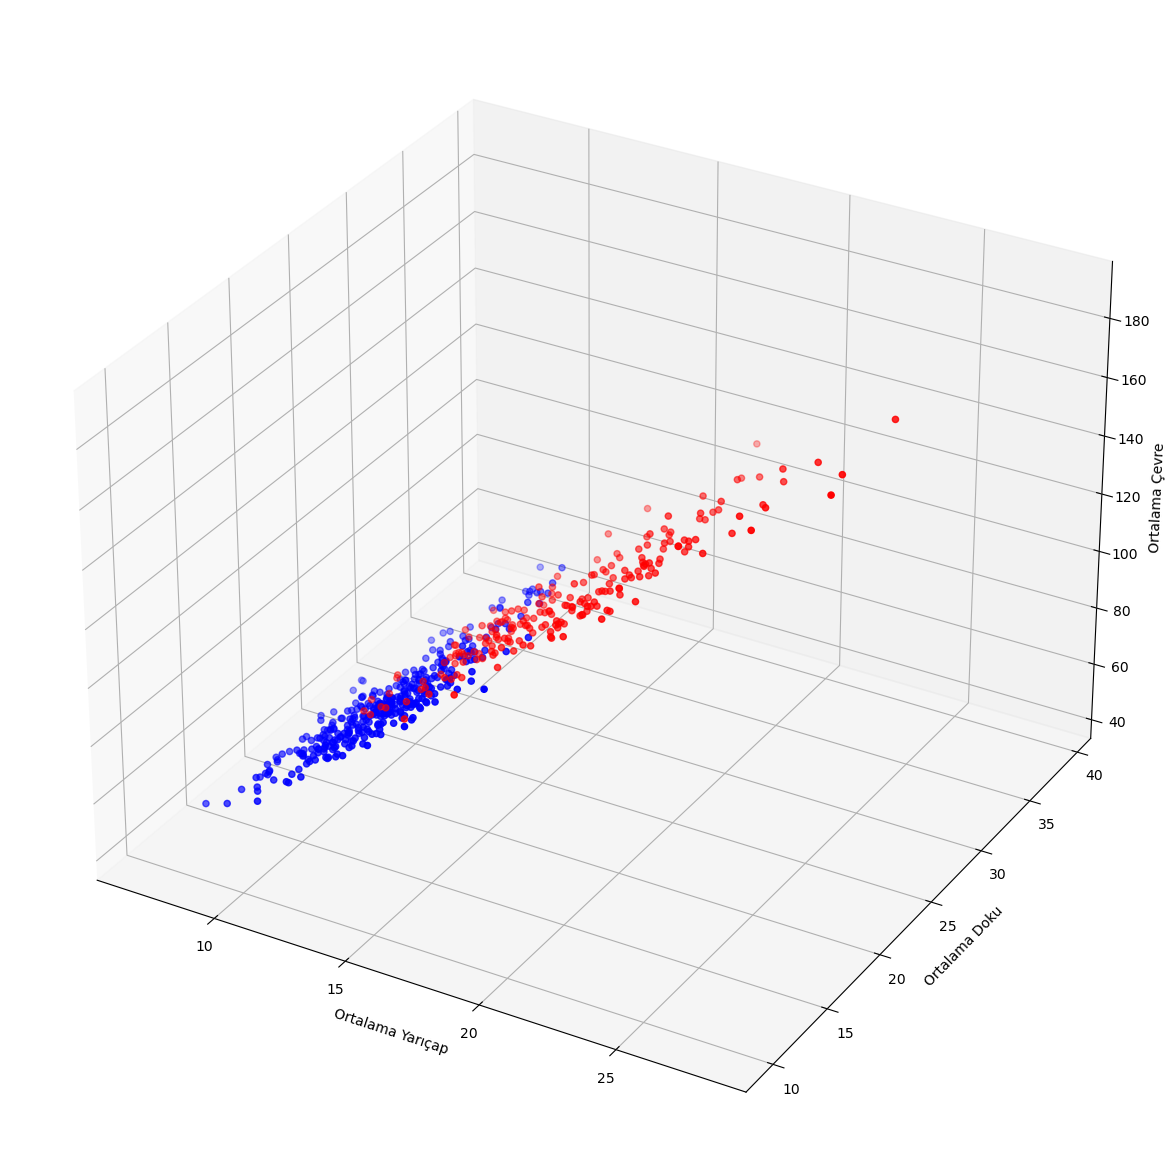

In [29]:
%matplotlib inline
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer()

# --- Veri setinden 3 boyutlu bir dizi oluşturma ---
X = []
for target in range(2):
    X.append([[], [], []])

for i in range(len(cancer.data)):
    if cancer.target[i] == 0:
        X[0][0].append(cancer.data[i][0])
        X[0][1].append(cancer.data[i][1])
        X[0][2].append(cancer.data[i][2])
    else:
        X[1][0].append(cancer.data[i][0])
        X[1][1].append(cancer.data[i][1])
        X[1][2].append(cancer.data[i][2])

colors = ("r", "b")

fig = plt.figure(figsize=(18, 15))
ax = fig.add_subplot(111, projection='3d')

for target, color in zip(range(2), colors):
    ax.scatter(X[target][0], X[target][1], X[target][2], c=color)

ax.set_xlabel("Ortalama Yarıçap")
ax.set_ylabel("Ortalama Doku")
ax.set_zlabel("Ortalama Çevre")
plt.show()

**Şekil 7.12:** 3D harita kullanarak üç unsur çizme

İki özellik kullanarak çizmek yerine, şimdi üçüncü bir özelliğe sahipsiniz: ortalama çevre. Şekil 7.12, üç özelliği 3D harita kullanarak göstermektedir.

Bu 3D grafiği Jupyter Notebook, statik olarak gösterir. Şekil 7.12'den görebileceğiniz gibi, üç özellik arasındaki ilişkilere gerçekten iyi bir bakış elde edemezsiniz. 3D grafiği daha iyi bir şekilde göstermenin çok daha iyi bir yolu, Jupyter Notebook dışında yukarıdaki kod parçasını çalıştırmaktır. Bunu yapmak için, kod parçasını (ilk satırı içeren " %matplotlib inline " ifadesi hariç) 3dplot.py adında bir dosyaya kaydedin. Ardından şu komutu Terminal'de çalıştırın:

In [30]:
$ python 3dplot.py

SyntaxError: invalid decimal literal (4236808405.py, line 1)

Bunu yaptığınızda, matplotlib, 3D grafiği göstermek için ayrı bir pencere açacaktır. En iyi yanı, onunla etkileşimde bulunabileceğinizdir. Farenizi sürükleyerek grafiği taşıyabilir ve üç özellik arasındaki ilişkileri daha iyi görselleştirebilirsiniz. Şekil 7.13, daha iyi bir perspektif sunar: tümör büyümesinin ortalama çevresi arttıkça, büyümenin kötü huylu olma şansı da artar.

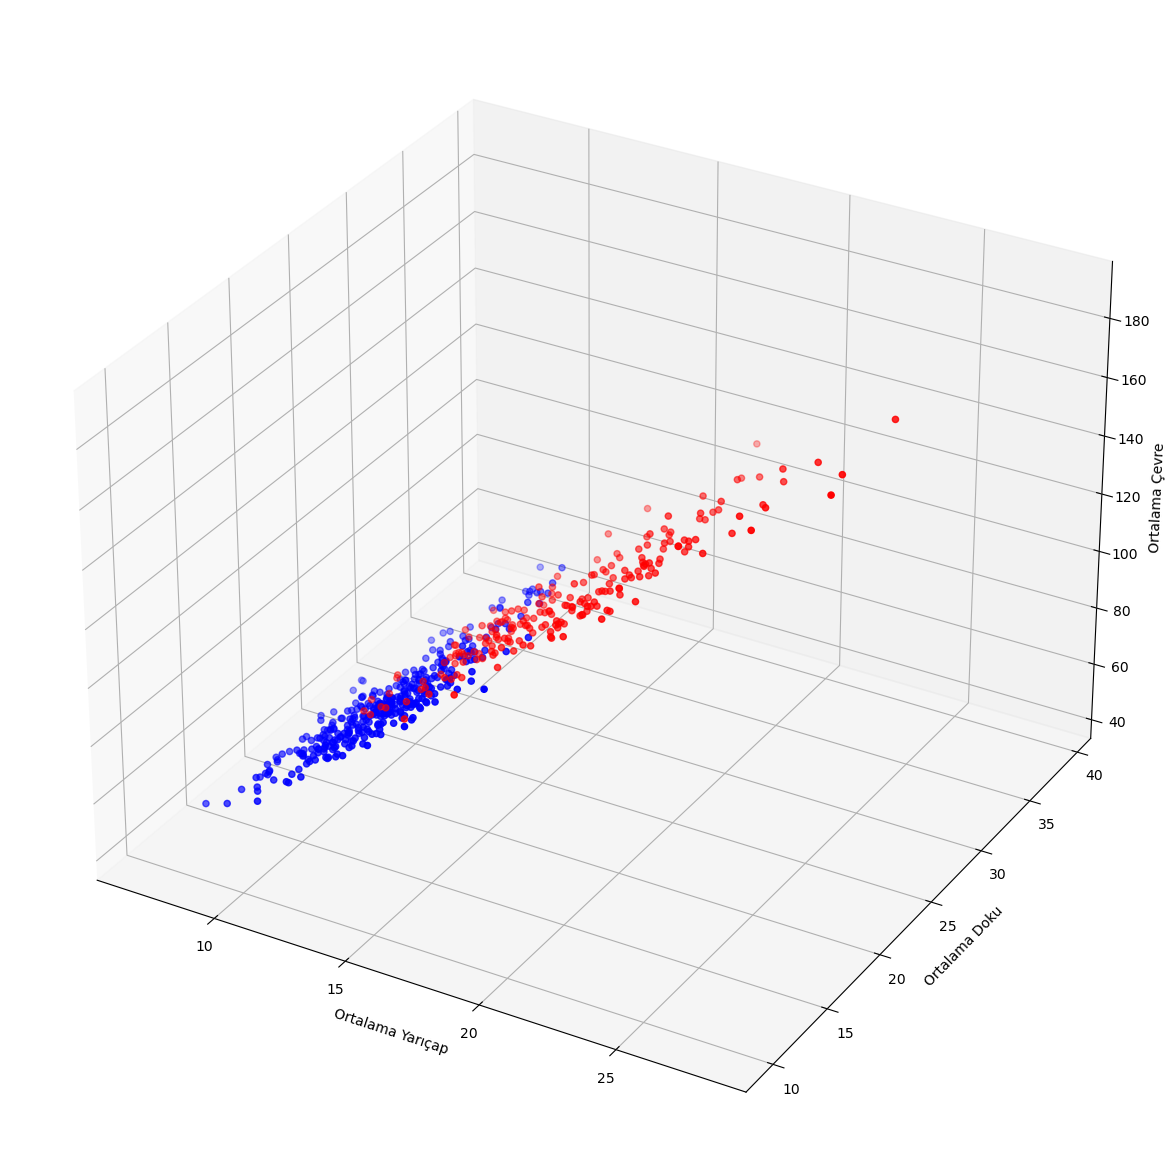

In [32]:
%matplotlib inline
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer()

# --- Veri setinden 3 boyutlu bir dizi oluşturma ---
X = []
for target in range(2):
    X.append([[], [], []])

for i in range(len(cancer.data)):
    if cancer.target[i] == 0:
        X[0][0].append(cancer.data[i][0])
        X[0][1].append(cancer.data[i][1])
        X[0][2].append(cancer.data[i][2])
    else:
        X[1][0].append(cancer.data[i][0])
        X[1][1].append(cancer.data[i][1])
        X[1][2].append(cancer.data[i][2])

colors = ("r", "b")

fig = plt.figure(figsize=(18, 15))
ax = fig.add_subplot(111, projection='3d')

for target, color in zip(range(2), colors):
    ax.scatter(X[target][0], X[target][1], X[target][2], c=color)

ax.set_xlabel("Ortalama Yarıçap")
ax.set_ylabel("Ortalama Doku")
ax.set_zlabel("Ortalama Çevre")
plt.show()

**Şekil 7.13:** Jupyter Notebook dışında uygulamayı çalıştırdığınızda 3D grafiği ile etkileşime girebilirsiniz.

### Tek Özellik Kullanarak Eğitim

Şimdi lojistik regresyon kullanarak bir tümörün kanserli olup olmadığını tahmin etmeyi deneyelim. Başlamak için, veri setinin sadece ilk özelliğini kullanalım: ortalama yarıçap. Aşağıdaki kod parçası, ortalama yarıçapa göre bir tümörün kötü huylu veya iyi huylu olup olmadığını gösteren bir saçılma grafiği çizer:

Şekil 7.14 saçılma grafiğini göstermektedir.

C:\Users\Furkan\AppData\Local\Temp\ipykernel_21096\590228892.py:12: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(x, y,


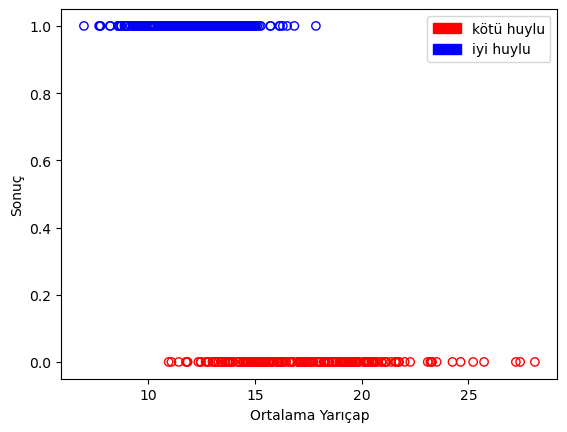

In [33]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer()  # Veri setini yükle
x = cancer.data[:, 0]  # Ortalama yarıçap
y = cancer.target  # 0: kötü huylu, 1: iyi huylu

colors = {0: 'red', 1: 'blue'}  # 0: kötü huylu, 1: iyi huylu
plt.scatter(x, y,
            facecolors='none',
            edgecolors=pd.DataFrame(cancer.target)[0].apply(lambda x: colors[x]),
            cmap=colors)

plt.xlabel("Ortalama Yarıçap")
plt.ylabel("Sonuç")

red = mpatches.Patch(color='red', label='kötü huylu')
blue = mpatches.Patch(color='blue', label='iyi huylu')
plt.legend(handles=[red, blue], loc=1)

**Şekil 7.14:** Tek özellik temelinde saçılma grafiği çizimi

Gördüğünüz gibi, bu, bir tümörün kanserli olup olmadığını tahmin etmek için logistic regresyon kullanmak için iyi bir fırsattır. Bir "s" eğrisi çizmeyi deneyebilirsiniz (yatay olarak ters çevrilmiş olsa da).

## Kesişim Noktası ve Katsayıyı Bulma

Scikit-learn, bir model eğitmek için logistic regresyon uygulamanıza olanak tanıyan LogisticRegression sınıfı ile gelir. Bu örnekte, veri setinin ilk özelliğini kullanarak bir model eğiteceksiniz:

In [34]:
from sklearn import linear_model
import numpy as np

log_regress = linear_model.LogisticRegression()

#--- modeli eğit ---
log_regress.fit(X = np.array(x).reshape(len(x),1),
                y = y)

#--- eğitilmiş modelin kesişim noktasını yazdır ---
print(log_regress.intercept_) # [ 8.19393897]

#--- eğitilmiş modelin katsayılarını yazdır ---
print(log_regress.coef_) # [[-0.54291739]]

[15.120902]
[[-1.02475609]]


Model eğitildikten sonra, şu anda en çok ilgilendiğimiz şey kesişim noktası ve katsayıdır. Şekil 7.10'daki formülü hatırlarsanız, kesişim β0 ve katsayı xβ'dir. Bu iki değeri bilmek, grafikteki noktaları uygun şekilde sığdırmaya çalışan sigmoid eğrisini çizmemize olanak tanır.

### Sigmoid Eğrisini Çizme

β0 ve xβ değerleri elde edildikten sonra, aşağıdaki kod parçasını kullanarak sigmoid eğrisini çizebilirsiniz:

C:\Users\Furkan\AppData\Local\Temp\ipykernel_21096\1811917988.py:7: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(x, y,


Text(0, 0.5, 'Olasılık')

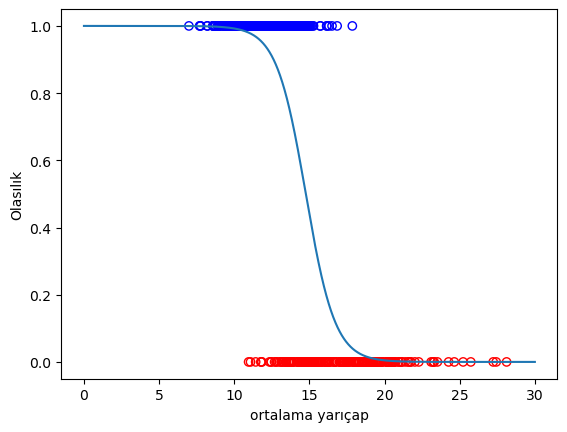

In [35]:
def sigmoid(x):
    return (1 / (1 + np.exp(-(log_regress.intercept_[0] + (log_regress.coef_[0][0] * x)))))

x1 = np.arange(0, 30, 0.01)
y1 = [sigmoid(n) for n in x1]

plt.scatter(x, y,
            facecolors='none',
            edgecolors=pd.DataFrame(cancer.target)[0].apply(lambda x: colors[x]),
            cmap=colors)
plt.plot(x1, y1)
plt.xlabel("ortalama yarıçap")
plt.ylabel("Olasılık")

Şekil 7.15, sigmoid eğrisini göstermektedir.

C:\Users\Furkan\AppData\Local\Temp\ipykernel_21096\1811917988.py:7: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(x, y,


Text(0, 0.5, 'Olasılık')

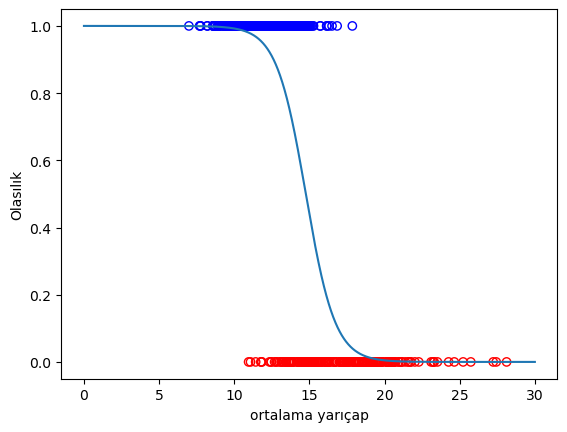

In [37]:
def sigmoid(x):
    return (1 / (1 + np.exp(-(log_regress.intercept_[0] + (log_regress.coef_[0][0] * x)))))

x1 = np.arange(0, 30, 0.01)
y1 = [sigmoid(n) for n in x1]

plt.scatter(x, y,
            facecolors='none',
            edgecolors=pd.DataFrame(cancer.target)[0].apply(lambda x: colors[x]),
            cmap=colors)
plt.plot(x1, y1)
plt.xlabel("ortalama yarıçap")
plt.ylabel("Olasılık")

**Şekil 7.15:** İki set noktaya uyan sigmoid eğrisi

### Tahminlerde Bulunma

Eğitilmiş modeli kullanarak bazı tahminler yapalım. Ortalama yarıçapı 20 olduğunda sonucu tahmin etmeyi deneyelim:

In [55]:
import numpy as np
from sklearn.linear_model import LogisticRegression

# Örnek bir model oluşturma
X = np.random.rand(100, 1)  # Örnek veri
y = np.random.randint(0, 2, 100)  # Örnek etiket

log_regress = LogisticRegression()
log_regress.fit(X, y)

# Girdiyi 2D array olarak yeniden şekillendirme
input_data = np.array([[20]])

print(log_regress.predict_proba(input_data))
print(log_regress.predict(input_data)[0])


[[0.01265478 0.98734522]]
1


Sonuçtan görebileceğiniz gibi, tahmin tümörün iyi huylu olduğudur.

## Tüm Özellikleri Kullanarak Modeli Eğitme

Önceki bölümde, modeli özelliklerden biri kullanarak özellikle eğittiniz. Şimdi modeli tüm özellikleri kullanarak eğitmeyi deneyelim ve ardından ne kadar iyi bir şekilde tahmin yapabildiğini görelim.

Önce veri setini yükleyin:

In [56]:
from sklearn.datasets import load_breast_cancer
cancer = load_breast_cancer() # Veri setini yükle

Veri setinin tüm satırlarını kullanarak modeli eğitmek yerine, eğitim ve test için iki sete böleceksiniz. Bunun için train_test_split() fonksiyonunu kullanacaksınız. Bu fonksiyon, verinizi rastgele eğitim ve test alt kümelerine böler. Aşağıdaki kod parçası, veri setini %75 eğitim ve %25 test setine böler:

In [57]:
from sklearn.model_selection import train_test_split
train_set, test_set, train_labels, test_labels = train_test_split(
    cancer.data, # özellikler
    cancer.target, # etiketler
    test_size = 0.25, # bölme oranı
    random_state = 1, # rastgele sayı
    stratify = cancer.target) # etiketlere göre rastgele

Şekil 7.16, veri setinin nasıl bölündüğünü göstermektedir. train_test_split() fonksiyonunun random_state parametresi, rastgele sayı üretecinin kullandığı tohumu belirtir. Eğer bu belirtilmezse, bu fonksiyonu her çalıştırdığınızda farklı bir eğitim ve test seti alırsınız. stratify parametresi, bölümün orantılı olması için hangi sütunu (özellik/etiket) belirtmenizi sağlar. Örneğin, belirtilen sütun, %80 0 ve %20 1 olan kategorik bir değişkense, eğitim ve test setleri her birinin %80'inde 0 ve %20'sinde 1 olacaktır.

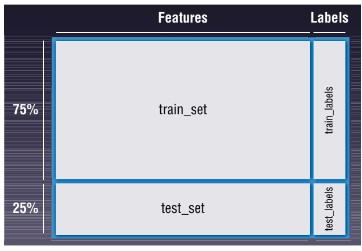

In [58]:
Image('Şekil 7.16.jpg')

**Şekil 7.16:** Veri setini eğitim ve test setlerine bölmek

Veri seti bölündükten sonra, şimdi modeli eğitme zamanıdır. Aşağıdaki kod parçası, logistic regresyon kullanarak modeli eğitir:

In [60]:
from sklearn import linear_model
x = train_set[:,0:30] # ortalama yarıçap
y = train_labels # 0: kötü huylu, 1: iyi huylu
log_regress = linear_model.LogisticRegression()
log_regress.fit(X = x,
                y = y)


C:\Users\Furkan\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

Bu örnekte, veri setindeki tüm 30 özellikle eğitiyoruz. Eğitim bittiğinde, kesişim ve model katsayılarını yazdıralım:

In [61]:
print(log_regress.intercept_)
print(log_regress.coef_)

[0.1028962]
[[ 0.58498544  0.52798102  0.50933063 -0.03114596 -0.01617425 -0.09103858
  -0.1290204  -0.05109663 -0.02967439 -0.00432678  0.02725417  0.13757289
   0.0281822  -0.11116845 -0.00143004 -0.02151674 -0.02945585 -0.00684584
  -0.00557545 -0.00205702  0.6774664  -0.57294062 -0.30701653 -0.00668105
  -0.03268111 -0.3080222  -0.38769045 -0.10447208 -0.08828368 -0.02879395]]


Aşağıdaki çıktı, kesişim ve katsayıları göstermektedir:

Veri setini 30 özellikle eğittiğimiz için, 30 katsayı vardır.

## Modeli Test Etme

Tahmin yapma zamanı geldi. Aşağıdaki kod parçası test setini kullanır ve tahminleri elde etmek için modele besler:

In [62]:
import pandas as pd

#---tahmin olasılıklarını al ve bir veri çerçevesine dönüştür---
preds_prob = pd.DataFrame(log_regress.predict_proba(X=test_set))

#---tahminlere sütun adları ata---
preds_prob.columns = ["Kötü Huylu", "İyi Huylu"]

#---tahmin edilen sınıf etiketlerini al---
preds = log_regress.predict(X=test_set)
preds_class = pd.DataFrame(preds)
preds_class.columns = ["Tahmin"]

#---gerçek teşhis---
original_result = pd.DataFrame(test_labels)
original_result.columns = ["Orijinal Sonuç"]

#---üç veri çerçevesini birleştir---
result = pd.concat([preds_prob, preds_class, original_result], axis=1)
print(result.head())


   Kötü Huylu     İyi Huylu  Tahmin  Orijinal Sonuç
0    0.999836  1.639308e-04       0               0
1    0.999750  2.501465e-04       0               0
2    0.174518  8.254822e-01       1               1
3    1.000000  5.954762e-09       0               0
4    0.088016  9.119836e-01       1               0


Tahminlerin sonuçları yazdırılır. Tahminler ve orijinal teşhis kolay karşılaştırma için yan yana gösterilir:

### Karmaşıklık Matrisini Elde Etme

Tahminleri test setiyle orijinal teşhisle birlikte yazdırmak yararlıdır, ancak bu modelin tümörün kanserli olup olmadığını ne kadar iyi tahmin ettiğine dair net bir resim vermez. Daha bilimsel bir yöntem karmaşıklık matrisini kullanmaktır. Karmaşıklık matrisi, gerçek ve tahmin edilen etiket sayısını ve bunların kaçının doğru sınıflandırıldığını gösterir. Karmaşıklık matrisini yazdırmak için Pandas'ın crosstab() fonksiyonunu kullanabilirsiniz:

In [63]:
#---tahminler vs gerçek tablosunu oluştur---
print("---Karmaşıklık Matrisi---")
print(pd.crosstab(preds, test_labels))

---Karmaşıklık Matrisi---
col_0   0   1
row_0        
0      48   4
1       5  86


crosstab() fonksiyonu iki faktörün basit bir çapraz tablosunu hesaplar. Önceki kod parçası aşağıdakini yazdırır:

Çıktı, Şekil 7.17'de gösterildiği şekilde yorumlanır.

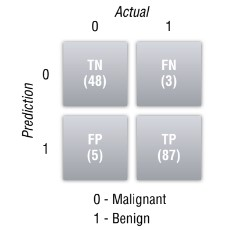

In [66]:
Image('Şekil 7.17.jpg')

**Şekil 7.17:** Tahmin için karmaşıklık matrisi

Sütunlar gerçek teşhisi (0 kötü huylu ve 1 iyi huylu) temsil eder. Satırlar tahmini temsil eder. Her bir kutu aşağıdakilerden birini temsil eder:

- **Gerçek Pozitif (TP):** Model pozitif olarak doğru tahmin eder. Bu örnekte, TP sayısı (87), bir tümörün iyi huylu olduğunu doğru tahminlerin sayısını gösterir.
- **Gerçek Negatif (TN):** Model negatif olarak doğru tahmin eder. Bu örnekte, tümörler kötü huylu olarak doğru tahmin edildi.
- **Yanlış Pozitif (FP):** Model pozitif olarak yanlış bir tahminde bulundu, ancak gerçek sonuç negatif. Bu örnekte, tümör aslında kötü huylu iken model tümörü iyi huylu olarak tahmin etti.
- **Yanlış Negatif (FN):** Model negatif olarak yanlış bir tahminde bulundu, ancak gerçek sonuç pozitif. Bu örnekte, tümör aslında iyi huylu iken model tümörü kötü huylu olarak tahmin etti.

Bu sayılar karmaşıklık matrisi olarak bilinir.

crosstab() fonksiyonu yerine confusion_matrix() fonksiyonunu kullanarak da karmaşıklık matrisini yazdırabilirsiniz:

In [68]:
from sklearn import metrics

#---karmaşıklık matrisini görüntüle---
print(metrics.confusion_matrix(y_true = test_labels,  # Gerçek etiketler
                               y_pred = preds))        # Tahmin edilen etiketler

[[48  5]
 [ 4 86]]


Çıktının satırlar ve sütunlar için yer değiştirdiğini unutmayın.

### Doğruluk, Duyarlılık, Hassasiyet ve Diğer Metriklerin Hesaplanması

Karmaşıklık matrisine dayanarak aşağıdaki metrikleri hesaplayabilirsiniz:

- Doğruluk (Accuracy): Bu, doğru tahminlerin toplam sayısının toplam tahmin sayısına bölünmesiyle tanımlanır, matematiksel olarak:

$$Doğruluk = \frac{TP+TN}{TP+TN+FP+FN}$$

Bu metrik kolay anlaşılırdır. Sonuçta, eğer model 100 örneğin 99'unu doğru tahmin ederse, doğruluk 0.99 olur ve gerçek dünyada oldukça etkileyici olurdu. Ancak şu durumu düşünün: Ekipmanın başarısızlığını örnek veriye dayanarak tahmin etmeye çalışıyorsunuz. 1.000 örneğin sadece üçü kusurlu. Eğer tüm sonuçlar için her zaman negatif (yani başarısızlık yok) döndüren basit bir algoritma kullanırsanız, doğruluk 997/1000'dir, bu da 0.997'dir. Bu oldukça etkileyici, ancak bu iyi bir algoritma olduğu anlamına mı gelir? Hayır. Eğer 1.000 öğenin veri setinde 500 kusurlu ürün varsa, doğruluk metriği hemen algoritmanın kusurunu gösterir. Kısacası, doğruluk, eşit dağılmış veri noktalarıyla en iyi çalışır, ancak çarpık bir veri seti için gerçekten kötü çalışır. Şekil 7.18, doğruluk için formülü özetler.

-  **Hassasiyet (Precision):** Bu metrik, TP / (TP + FP) olarak tanımlanır. Bu metrik, doğru pozitif tahminlerin sayısıyla ilgilidir. Hassasiyeti şöyle düşünebilirsiniz: "Pozitif olarak tahmin edilenlerin kaçı gerçekten doğru tahmin edildi?" Şekil 7.19, hassasiyet için formülü özetler.

- **Duyarlılık (Recall) (aynı zamanda True Positive Rate (TPR) olarak da bilinir):** Bu metrik, TP / (TP + FN) olarak tanımlanır. Bu metrik, doğru tahmin edilen pozitif olayların sayısıyla ilgilidir. Duyarlılığı şöyle düşünebilirsiniz: "Pozitif olayların kaçı doğru tahmin edildi?" Şekil 7.20, duyarlılık için formülü özetler.

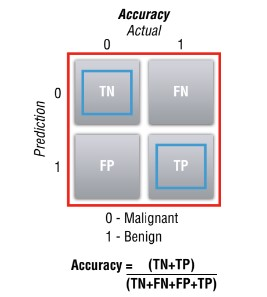

In [69]:
Image('Şekil 7.18.jpg')

**Şekil 7.18:** Doğruluğu hesaplama formülü

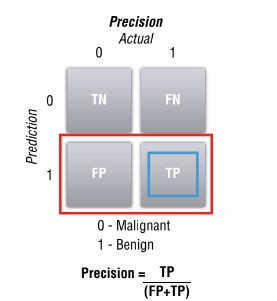

In [70]:
Image('Şekil 7.19.jpg')

**Şekil 7.19:** Hassasiyeti hesaplama formülü

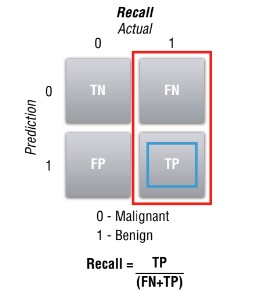

In [71]:
Image('Şekil 7.20.jpg')

**Şekil 7.20:** Duyarlılığı hesaplama formülü

- **F1 Skoru:** Bu metrik, $F1 Skoru = 2  x  \frac{hassasiyet x duyarlılık}{hassasiyet + duyarlılık}$ olarak tanımlanır. Bu, hassasiyet ve duyarlılığın harmonik ortalaması olarak bilinir ve algoritmanın değerlendirmesini tek bir sayıda özetlemenin iyi bir yoludur.

-Yanlış Pozitif Oranı (FPR): Bu metrik, FP / (FP + TN) olarak tanımlanır. FPR, tüm negatif veri noktalarına göre yanlışlıkla pozitif olarak kabul edilen negatif veri noktalarının oranına karşılık gelir. Diğer bir deyişle, FPR ne kadar yüksekse, yanlışlıkla sınıflandırılan negatif veri noktaları o kadar fazla olur.

Hassasiyet ve duyarlılık kavramı hemen anlaşılmayabilir, ancak aşağıdaki senaryoyu düşünürseniz çok daha açık olacaktır. Meme kanseri teşhisini ele alalım. Eğer kötü huylu bir tümör negatif olarak ve iyi huylu bir tümör pozitif olarak temsil edilirse:

- Eğer hassasiyet veya duyarlılık yüksekse, bu, daha fazla iyi huylu tümörlü hastanın doğru teşhis edildiği anlamına gelir, bu da algoritmanın iyi olduğunu gösterir.
- Eğer hassasiyet düşükse, bu, daha fazla kötü huylu tümörlü hastanın iyi huylu olarak teşhis edildiği anlamına gelir.
- Eğer duyarlılık düşükse, bu, daha fazla iyi huylu tümörlü hastanın kötü huylu olarak teşhis edildiği anlamına gelir.

Son iki nokta için, düşük bir hassasiyet düşük bir duyarlılıktan daha ciddidir (ancak meme kanserine sahip olmadığınızda yanlış teşhis edilirseniz muhtemelen gereksiz tedavi ve zihinsel acıya yol açar) çünkü hastanın tedaviyi kaçırmasına ve potansiyel olarak ölümüne neden olur. Bu nedenle, meme kanseri teşhisi gibi durumlar için, bir ML algoritmasının etkinliğini değerlendirirken hem hassasiyeti hem de duyarlılık metriklerini göz önünde bulundurmak önemlidir.

Modelin doğruluğunu elde etmek için, modelin score() fonksiyonunu kullanabilirsiniz:

In [73]:
#---tahminin doğruluğunu al---
print("---Doğruluk---")
print(log_regress.score(X = test_set, y = test_labels))

---Doğruluk---
0.9370629370629371


Aşağıdaki sonucu görmelisiniz:

Modelin hassasiyetini, duyarlılığını ve F1 skorunu elde etmek için, metrics modülünün classification_report() fonksiyonunu kullanın:

In [74]:
# Ortak sınıflandırma metriklerinin özetini görüntüle
print("---Metrikler---")
print(metrics.classification_report(y_true = test_labels, y_pred = preds))

---Metrikler---
              precision    recall  f1-score   support

           0       0.92      0.91      0.91        53
           1       0.95      0.96      0.95        90

    accuracy                           0.94       143
   macro avg       0.93      0.93      0.93       143
weighted avg       0.94      0.94      0.94       143



Aşağıdaki sonuçları göreceksiniz:

### Alıcı İşletim Karakteristikleri (ROC) Eğrisi

Bu kadar çok metrik mevcutken, bir algoritmanın etkinliğini incelemenin kolay bir yolu nedir? Bir yol, Alıcı İşletim Karakteristikleri (ROC) eğrisi olarak bilinen bir eğriyi çizmektir. ROC eğrisi, çeşitli eşik ayarlarında TPR'yi FPR'ye karşı çizerek oluşturulur.

Peki bu nasıl çalışır? Basit bir örnek üzerinden gidelim. Üzerinde çalıştığınız mevcut projeyi kullanarak, varsayılan 0.5 eşiği temel alınarak karmaşıklık matrisini türettiniz (tüm bu tahmin edilen olasılıkların 0.5'e eşit veya daha az olduğu bir sınıfa, 0.5'ten büyük olanların diğer bir sınıfa ait olduğu anlamına gelir). Bu karmaşıklık matrisini kullanarak, ardından duyarlılığı, hassasiyeti ve dolayısıyla FPR ve TPR'yi bulursunuz. FPR ve TPR bulunduktan sonra, Şekil 7.21'de gösterildiği gibi grafiğe noktayı çizebilirsiniz.

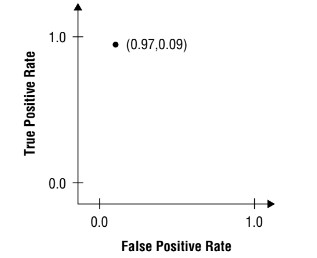

In [75]:
Image('Şekil 7.21.jpg')

**Şekil 7.21:** Eşik değeri 0.5 için nokta

Ardından, eşik değeri 0 için karmaşıklık matrisini yeniden oluşturun ve duyarlılığı, hassasiyeti, FPR ve TPR'yi yeniden hesaplayın. Yeni FPR ve TPR kullanarak, grafiğe başka bir nokta çizersiniz. Ardından, 0.1, 0.2, 0.3 ve böyle devam ederek 1.0'a kadar olan eşikler için bu süreci tekrar edersiniz.

Eşik değeri 0'da, bir tümörün iyi huylu (1) olarak sınıflandırılması için tahmin edilen olasılığın 0'dan büyük olması gerekir. Dolayısıyla, tüm tahminler iyi huylu (1) olarak sınıflandırılır. Şekil 7.22, TPR ve FPR'yi nasıl hesaplayacağınızı gösterir. Eşik değeri 0 için, TPR ve FPR her ikisi de 1'dir.

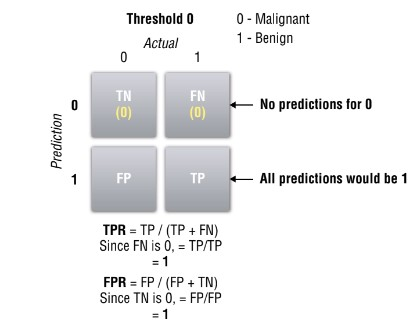

In [80]:
Image('Şekil 7.22.jpg')

**Şekil 7.22:** Eşik 0 için TPR ve FPR değeri

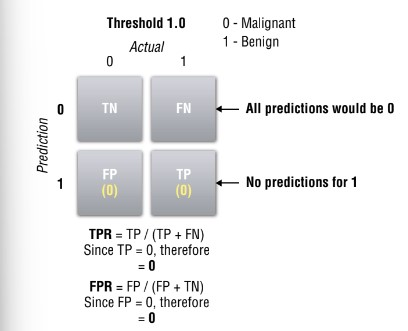

In [76]:
Image('Şekil 7.23.jpg')

**Şekil 7.23:** Eşik değeri 1 için TPR ve FPR değeri

Şimdi grafiğimize iki daha nokta çizebiliriz (Şekil 7.24'e bakın).

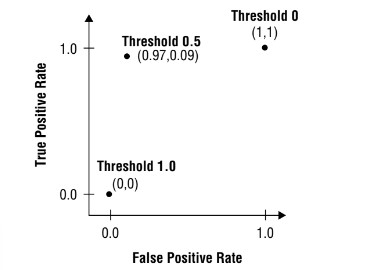

In [77]:
Image('Şekil 7.24.jpg')

**Şekil 7.24:** Eşik değerleri 0, 0.5 ve 1.0 için noktaların çizilmesi

Ardından diğer eşik değerleri için metrikleri hesaplarsınız. Farklı eşik değerlerine göre tüm metrikleri hesaplamak çok zahmetli bir süreçtir. Neyse ki, Scikit-learn'ün roc_curve() fonksiyonu, sağlanan test etiketleri ve tahmin edilen olasılıklara dayanarak FPR ve TPR'yi otomatik olarak hesaplar:

In [78]:
from sklearn.metrics import roc_curve, auc
#---test setini kullanarak tahmin edilen olasılıkları bul---
probs = log_regress.predict_proba(test_set)
preds = probs[:,1]
#---FPR, TPR ve eşik değerini bul---
fpr, tpr, threshold = roc_curve(test_labels, preds)

roc_curve() fonksiyonu, FPR, TPR ve eşik değerini içeren bir tuple döndürür. Değerleri görmek için onları yazdırabilirsiniz:

In [79]:
print(fpr)
print(tpr)
print(threshold)

[0.         0.         0.         0.01886792 0.01886792 0.03773585
 0.03773585 0.05660377 0.05660377 0.0754717  0.0754717  0.13207547
 0.13207547 0.1509434  0.1509434  0.22641509 0.22641509 1.        ]
[0.         0.01111111 0.66666667 0.66666667 0.87777778 0.87777778
 0.91111111 0.91111111 0.93333333 0.93333333 0.95555556 0.95555556
 0.97777778 0.97777778 0.98888889 0.98888889 1.         1.        ]
[           inf 9.99939819e-01 9.80418118e-01 9.80026184e-01
 9.17187330e-01 9.11983604e-01 8.65482863e-01 8.34761589e-01
 8.25482238e-01 7.68224932e-01 6.92080385e-01 2.94074598e-01
 2.57843126e-01 2.37078815e-01 7.48107152e-02 3.11664932e-02
 1.08336713e-02 1.89316423e-20]


Aşağıdaki sonuçları görmelisiniz:

Çıktıdan görebileceğiniz gibi, eşik değeri 0.99999 (9.99e-01) ile başlar ve 1.311e-21'e kadar düşer.

### ROC Eğrisini Çizme ve Eğri Altındaki Alanı (AUC) Bulma 

ROC'u çizmek için, fpr ve tpr değişkenlerinde saklanan değerleri kullanarak matplotlib kullanabilirsiniz. ROC eğrisi altındaki alanı bulmak için auc() fonksiyonunu kullanabilirsiniz:

Şekil 7.25, ROC eğrisini ve AUC'yi göstermektedir.

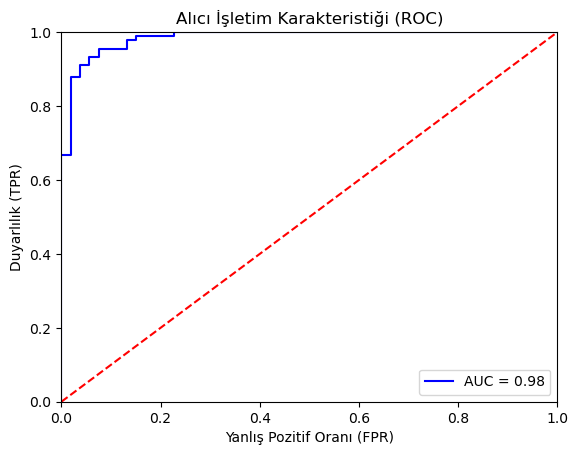

In [84]:
roc_auc = auc(fpr, tpr)
import matplotlib.pyplot as plt

plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('Duyarlılık (TPR)')
plt.xlabel('Yanlış Pozitif Oranı (FPR)')
plt.title('Alıcı İşletim Karakteristiği (ROC)')
plt.legend(loc='lower right')  # 'alt sağ' yerine 'lower right' kullanıyoruz
plt.show()

**Şekil 7.25:** ROC eğrisini çizme ve AUC'yi hesaplama

## Özet

Bu bölümde, başka bir denetimli makine öğrenimi algoritması olan lojistik regresyonu öğrendiniz. İlk olarak, logit fonksiyonu hakkında ve onu bir sigmoid fonksiyonuna nasıl dönüştüreceğiniz hakkında bilgi edindiniz. Ardından lojistik regresyonu meme kanseri veri kümesine uyguladınız ve bir tümörün malign veya benign olup olmadığını tahmin etmek için kullandınız. Daha da önemlisi, bu bölüm bir makine öğrenimi algoritmasının etkinliğini belirlemede yararlı olan bazı metrikler hakkında bilgi verdi. Ayrıca, bir ROC eğrisinin ne olduğunu, nasıl çizileceğini ve eğri altındaki alanın nasıl hesaplanacağını öğrendiniz.